In [52]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Import the Blind Insight client
import sys
sys.path.append('.')
from blind_insight_client import BlindInsightClient, load_iris_from_blind

# Batch means (integer-scaled) over all rows, in batches using transaction_id
from blind_insight_client import BlindInsightClient

import numpy as np
import warnings

# Suppress SSL warnings for local development
warnings.filterwarnings('ignore', message='Unverified HTTPS request')

# Import the Blind Insight client
import sys
sys.path.append('.')
from blind_insight_client import BlindInsightClient


In [53]:
# Encrypted avg of sepal-width per class (integer-scaled data)
from blind_insight_client import BlindInsightClient

# Configuration - Plaintext ML example (illustrative)
# NOTE: This decrypts data; for encrypted-only workflows see the section below.
ORGANIZATION = "demo"
TRAINING_DATASET_SLUG = "fraud-analysis-training"
API_URL = "https://proxy.local.blindinsight.io/"

USERNAME = "data_owner@localhost"  # Your Blind Insight account email
PASSWORD = "blindinsight"  # Your Blind Insight account password

SCHEMA_SLUG = "fraud-analysis-schema"

REAL_DATASET_SLUG = "fraud-analysis"
TRAINING_DATASET_SLUG = "fraud-analysis-training"

REAL_DATA_SCHEMA_ID = "i9yp3TutxNsCp3fgNWE4p2"
TRAINING_SCHEMA_ID = "iEbXomadeyp3JcDfZMFLYp"

In [54]:
def agg_value(resp):
    recs = resp.get("records", [])
    if not recs:
        raise ValueError(f"Unexpected aggregation response: {resp}")
    rec0 = recs[0]
    if "data" in rec0 and isinstance(rec0["data"], dict) and "value" in rec0["data"]:
        v = rec0["data"].get("value")
        return float(v) if v is not None else 0.0
    if "value" in rec0:
        v = rec0.get("value")
        return float(v) if v is not None else 0.0
    raise ValueError(f"Unexpected aggregation response shape: {resp}")

In [55]:
# Batch means (integer-scaled) over all rows, in batches using transaction_id
from blind_insight_client import BlindInsightClient

import numpy as np
import warnings

# Suppress SSL warnings for local development
warnings.filterwarnings('ignore', message='Unverified HTTPS request')

# Import the Blind Insight client
import sys
sys.path.append('.')
from blind_insight_client import BlindInsightClient

client = BlindInsightClient(api_url=API_URL, username=USERNAME, password=PASSWORD, verify_ssl=False)
features = [
    "amount",
    "transaction_type_ATM",
    "transaction_type_Online",
    "transaction_type_POS",
    "transaction_type_QR",
    "merchant_category_Clothing",
    "merchant_category_Electronics",
    "merchant_category_Food",
    "merchant_category_Grocery",
    "merchant_category_Travel",
    "country_DE",
    "country_FR",
    "country_NG",
    "country_TR",
    "country_UK",
    "country_US",
    "hour",
]
schema = {"type": "object", "properties": {"hour": {"type": "integer", "maximum": 23, "minimum": 0}, "amount": {"type": "integer", "maximum": 12000, "minimum": 0}, "user_id": {"type": "integer", "maximum": 1000, "minimum": 0}, "is_fraud": {"type": "integer", "maximum": 1, "minimum": 0}, "country_DE": {"type": "integer", "maximum": 1, "minimum": 0}, "country_FR": {"type": "integer", "maximum": 1, "minimum": 0}, "country_NG": {"type": "integer", "maximum": 1, "minimum": 0}, "country_TR": {"type": "integer", "maximum": 1, "minimum": 0}, "country_UK": {"type": "integer", "maximum": 1, "minimum": 0}, "country_US": {"type": "integer", "maximum": 1, "minimum": 0}, "dataset_order": {"type": "integer", "maximum": 500, "minimum": 0}, "ip_risk_score": {"type": "integer", "maximum": 100, "minimum": 0}, "transaction_id": {"type": "integer", "maximum": 10000, "minimum": 0}, "device_risk_score": {"type": "integer", "maximum": 100, "minimum": 0}, "transaction_type_QR": {"type": "integer", "maximum": 1, "minimum": 0}, "transaction_type_ATM": {"type": "integer", "maximum": 1, "minimum": 0}, "transaction_type_POS": {"type": "integer", "maximum": 1, "minimum": 0}, "merchant_category_Food": {"type": "integer", "maximum": 1, "minimum": 0}, "transaction_type_Online": {"type": "integer", "maximum": 1, "minimum": 0}, "merchant_category_Travel": {"type": "integer", "maximum": 1, "minimum": 0}, "merchant_category_Grocery": {"type": "integer", "maximum": 1, "minimum": 0}, "merchant_category_Clothing": {"type": "integer", "maximum": 1, "minimum": 0}, "merchant_category_Electronics": {"type": "integer", "maximum": 1, "minimum": 0}}}

def get_max_range(feature):
    """Get the maximum value for a feature from the schema."""
    return schema["properties"].get(feature, {}).get("maximum", 1)

batch_size = 10
SCHEMA_ID = TRAINING_SCHEMA_ID
DATASET_SLUG = TRAINING_DATASET_SLUG

# Reuse agg_value if defined; otherwise define here
def agg_value(resp):
    recs = resp.get("records", [])
    if not recs:
        raise ValueError(f"Unexpected aggregation response: {resp}")
    rec0 = recs[0]
    if "data" in rec0 and isinstance(rec0["data"], dict) and "value" in rec0["data"]:
        v = rec0["data"].get("value")
        return float(v) if v is not None else 0.0
    if "value" in rec0:
        v = rec0.get("value")
        return float(v) if v is not None else 0.0
    raise ValueError(f"Unexpected aggregation response shape: {resp}")

# Get total count first
print("Getting total record count...")
count_resp = client.aggregate(
    organization=ORGANIZATION,
    dataset_slug=DATASET_SLUG,
    schema_slug=SCHEMA_SLUG,
    agg_filter="dataset_order:count(0~100000)",
    decrypt=False,
    schema_id=SCHEMA_ID
)
total_count = int(agg_value(count_resp))
print(f"Total records: {total_count}")
total_rows = total_count

# Compute aggregations over the entire dataset (not batched by transaction_id)
# Since transaction_ids are random/sparse, we aggregate over all records at once
print(f"\nComputing mean for each feature across all {total_count} records:\n")

for feature in features[:5]:
    try:
        # Use a wide range to cover all possible values
        max_range = get_max_range(feature)
        resp = client.aggregate(
            organization=ORGANIZATION,
            dataset_slug=DATASET_SLUG,
            schema_slug=SCHEMA_SLUG,
            agg_filter=f"{feature}:avg(0~{max_range})",
            decrypt=False,
            schema_id=SCHEMA_ID
        )
        mean_val = agg_value(resp)
        print(f"  mean {feature}: {mean_val:.3f}")
    except Exception as e:
        print(f"  Error with {feature}: {str(e)[:100]}")

# Now compute means by fraud status (more useful for fraud detection)
# print("\n--- Mean by Fraud Status ---")
# for is_fraud in [0, 1]:
#     label = "Fraud" if is_fraud else "Legitimate"
#     print(f"\n{label} transactions (is_fraud={is_fraud}):")
#     for feature in features[:5]:  # Just first 5 features for brevity
#         try:
#             max_range = 1000 if feature == "amount" else 100
#             resp = client.aggregate(
#                 organization=ORGANIZATION,
#                 dataset_slug=DATASET_SLUG,
#                 schema_slug=SCHEMA_SLUG,
#                 agg_filter=f"{feature}:avg(0~{max_range})",
#                 extra_filters=[f"is_fraud:{is_fraud}"],
#                 decrypt=False,
#                 schema_id=SCHEMA_ID
#             )
#             mean_val = agg_value(resp)
#             print(f"  mean {feature}: {mean_val:.3f}")
#         except Exception as e:
#             print(f"  Error with {feature}: {str(e)[:100]}")



# for feature in features[:5]:  # Just first 5 features for brevity
#     start = 0
#     while start < total_rows:
#         end = min(start + batch_size - 1, total_rows - 1)
#         print(f"\nBatch {start}-{end}:")
#         try:
#             max_range = get_max_range(feature)
#             resp = client.aggregate(
#                 organization=ORGANIZATION,
#                 dataset_slug=DATASET_SLUG,
#                 schema_slug=SCHEMA_SLUG,
#                 agg_filter=f"{feature}:avg(0~{max_range})",
#                 # extra_filters=[f"transaction_id:1~100"],
#                 extra_filters=[f"dataset_order:0~10000"],
#                 decrypt=False,
#                 schema_id=SCHEMA_ID
#             )
#             mean_val = agg_value(resp)
#             print(f"  mean {feature}: {mean_val:.3f}")
#         except Exception as e:
#             print(f"  Error with {feature}: {str(e)[:100]}")
#         start += batch_size

print(f"\nStarting batch mean aggregation for each feature across using batch size {batch_size}:\n")
            
start = 0
while start < total_rows / 20:
    end = min(start + batch_size - 1, total_rows - 1)
    batch_filter = f"dataset_order:{start}~{end}"
    print(f"\nBatch {start}-{end}:")
    for feature in features[:5]:
        max_range = get_max_range(feature)
        resp = client.aggregate(
            organization=ORGANIZATION,
            dataset_slug=DATASET_SLUG,
            schema_slug=SCHEMA_SLUG,
            agg_filter=f"{feature}:avg(0~{max_range})",
            extra_filters=[batch_filter],
            decrypt=False,
            schema_id=SCHEMA_ID
        )
        mean_val = agg_value(resp)
        print(f"  mean {feature}: {mean_val:.3f}")
    start += batch_size


# for feature in features:
#     try:
#         # Use a wide range to cover all possible values
#         max_range = get_max_range(feature)00
#         resp = client.aggregate(
#             organization=ORGANIZATION,
#             dataset_slug=DATASET_SLUG,
#             schema_slug=SCHEMA_SLUG,
#             agg_filter=f"{feature}:avg(0~{max_range})",
#             decrypt=False,
#             schema_id=SCHEMA_ID
#         )
    #     mean_val = agg_value(resp)
    #     print(f"  mean {feature}: {mean_val:.3f}")
    # except Exception as e:
    #     print(f"  Error with {feature}: {str(e)[:100]}")

print("\nAggregation complete!")

Getting total record count...
Total records: 500

Computing mean for each feature across all 500 records:

  mean amount: 916.804
  mean transaction_type_ATM: 0.250
  mean transaction_type_Online: 0.266
  mean transaction_type_POS: 0.234
  mean transaction_type_QR: 0.250

Starting batch mean aggregation for each feature across using batch size 10:


Batch 0-9:
  mean amount: 2511.100
  mean transaction_type_ATM: 0.400
  mean transaction_type_Online: 0.100
  mean transaction_type_POS: 0.200
  mean transaction_type_QR: 0.300

Batch 10-19:
  mean amount: 1251.200
  mean transaction_type_ATM: 0.600
  mean transaction_type_Online: 0.200
  mean transaction_type_POS: 0.100
  mean transaction_type_QR: 0.100

Batch 20-29:
  mean amount: 1713.400
  mean transaction_type_ATM: 0.300
  mean transaction_type_Online: 0.200
  mean transaction_type_POS: 0.000
  mean transaction_type_QR: 0.500

Batch 30-39:
  mean amount: 2025.500
  mean transaction_type_ATM: 0.100
  mean transaction_type_Online: 0.400


In [56]:
# Load decrypted data for scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd


print("Loading decrypted data from Blind Insight...")

# Load data as DataFrame (this decrypts the data)
df_raw = client.load_data(
    organization=ORGANIZATION,
    dataset_slug=DATASET_SLUG,
    schema_slug=SCHEMA_SLUG,
    limit=10000,
    decrypt=True,
    schema_id=SCHEMA_ID
)

print(f"Loaded {len(df_raw)} records")

# The data is nested inside the 'data' column - extract it
if 'data' in df_raw.columns:
    # Flatten the nested data dictionary into columns
    df = pd.DataFrame(df_raw['data'].tolist())
else:
    df = df_raw

print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['is_fraud'].value_counts())

Loading decrypted data from Blind Insight...
Loaded 500 records
Columns: ['amount', 'country_DE', 'country_FR', 'country_NG', 'country_TR', 'country_UK', 'country_US', 'dataset_order', 'device_risk_score', 'hour', 'ip_risk_score', 'is_fraud', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel', 'transaction_id', 'transaction_type_ATM', 'transaction_type_Online', 'transaction_type_POS', 'transaction_type_QR', 'user_id']

Class distribution:
is_fraud
1    250
0    250
Name: count, dtype: int64


In [57]:
# Prepare features and target
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = [
    'amount', 'hour', 'device_risk_score', 'ip_risk_score',
    'country_DE', 'country_FR', 'country_NG', 'country_TR', 'country_UK', 'country_US',
    'merchant_category_Clothing', 'merchant_category_Electronics', 
    'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel',
    'transaction_type_ATM', 'transaction_type_Online', 
    'transaction_type_POS', 'transaction_type_QR'
]

# Filter to only existing columns
available_cols = [c for c in feature_cols if c in df.columns]
print(f"Using {len(available_cols)} features: {available_cols}")

X = df[available_cols].values.astype(np.float64)
y = df['is_fraud'].values.astype(np.float64)

# Check for NaN/inf values
print(f"\nData quality check:")
print(f"  NaN values in X: {np.isnan(X).sum()}")
print(f"  Inf values in X: {np.isinf(X).sum()}")

# Replace any NaN/inf with 0
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features to prevent numerical overflow in logistic regression
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Verify scaling worked
print(f"\nAfter scaling:")
print(f"  X_train mean: {X_train.mean():.6f}, std: {X_train.std():.6f}")
print(f"  X_train min: {X_train.min():.3f}, max: {X_train.max():.3f}")
print(f"  NaN in X_train: {np.isnan(X_train).sum()}, Inf: {np.isinf(X_train).sum()}")

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Using 19 features: ['amount', 'hour', 'device_risk_score', 'ip_risk_score', 'country_DE', 'country_FR', 'country_NG', 'country_TR', 'country_UK', 'country_US', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel', 'transaction_type_ATM', 'transaction_type_Online', 'transaction_type_POS', 'transaction_type_QR']

Data quality check:
  NaN values in X: 0
  Inf values in X: 0

After scaling:
  X_train mean: 0.000000, std: 1.000000
  X_train min: -1.865, max: 6.124
  NaN in X_train: 0, Inf: 0

Training set: 400 samples
Test set: 100 samples


In [58]:
# Train Logistic Regression model
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

print("Training Logistic Regression model...")

model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
model.fit(X_train, y_train)

print("Model trained successfully!")

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*50}")
print(f"LOGISTIC REGRESSION RESULTS (Plaintext)")
print(f"{'='*50}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Show prediction distribution
print(f"\nPrediction distribution:")
print(f"  Predicted Legitimate (0): {(y_pred == 0).sum()}")
print(f"  Predicted Fraud (1): {(y_pred == 1).sum()}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud'], zero_division=0))

Training Logistic Regression model...
Model trained successfully!

LOGISTIC REGRESSION RESULTS (Plaintext)
Accuracy: 1.0000 (100.00%)

Prediction distribution:
  Predicted Legitimate (0): 50
  Predicted Fraud (1): 50

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00        50
       Fraud       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [59]:
# Feature importance (from logistic regression coefficients)
print("Feature Importance (by coefficient magnitude):\n")

coef_importance = list(zip(available_cols, model.coef_[0]))
coef_importance.sort(key=lambda x: abs(x[1]), reverse=True)

for feature, coef in coef_importance[:10]:
    direction = "↑ fraud" if coef > 0 else "↓ fraud"
    print(f"  {feature:35s} {coef:+.4f} ({direction})")

Feature Importance (by coefficient magnitude):

  device_risk_score                   +2.4352 (↑ fraud)
  ip_risk_score                       +2.4286 (↑ fraud)
  amount                              +0.7863 (↑ fraud)
  country_NG                          +0.3704 (↑ fraud)
  hour                                -0.3038 (↓ fraud)
  country_TR                          -0.1078 (↓ fraud)
  country_FR                          -0.1008 (↓ fraud)
  country_US                          -0.0810 (↓ fraud)
  merchant_category_Food              +0.0445 (↑ fraud)
  merchant_category_Electronics       -0.0413 (↓ fraud)


# 🔐 Encrypted Machine Learning

## Building a Fraud Classifier Using Only Encrypted Aggregations

This section demonstrates how to build a machine learning classifier **without ever decrypting the data**. 
We use encrypted aggregations (mean, count) to compute class-conditional statistics, then derive a 
linear classifier similar to Linear Discriminant Analysis (LDA).

### The Approach:
1. **Compute class means**: For each feature, compute mean when `is_fraud=0` and `is_fraud=1`
2. **Compute class priors**: Get the proportion of fraud vs legitimate transactions  
3. **Build classifier**: Use the difference in means to create decision weights
4. **Compare**: Match results against plaintext logistic regression

In [60]:
# Step 1: Compute class-conditional means using ONLY encrypted aggregations
# This is the training phase - we learn model parameters without seeing raw data
# NOTE: This cell uses schema, get_max_range, and agg_value from cell 3

import numpy as np
import warnings
warnings.filterwarnings('ignore', message='Unverified HTTPS request')

print("=" * 60)
print("🔐 ENCRYPTED MODEL TRAINING")
print("=" * 60)
print("\nComputing class-conditional statistics using encrypted aggregations...")
print("(No raw data is decrypted during this process)\n")

# Use the same features as defined in cell 3
encrypted_features = features  # Reuse from cell 3

# Get class counts
print("Step 1: Getting class distribution...")
count_fraud = agg_value(client.aggregate(
    organization=ORGANIZATION,
    dataset_slug=DATASET_SLUG,
    schema_slug=SCHEMA_SLUG,
    agg_filter="is_fraud:count(1~1)",
    decrypt=False,
    schema_id=SCHEMA_ID
))

count_legit = agg_value(client.aggregate(
    organization=ORGANIZATION,
    dataset_slug=DATASET_SLUG,
    schema_slug=SCHEMA_SLUG,
    agg_filter="is_fraud:count(0~0)",
    decrypt=False,
    schema_id=SCHEMA_ID
))

total_count = count_fraud + count_legit
prior_fraud = count_fraud / total_count
prior_legit = count_legit / total_count

print(f"  Legitimate (is_fraud=0): {count_legit} ({prior_legit*100:.1f}%)")
print(f"  Fraud (is_fraud=1):      {count_fraud} ({prior_fraud*100:.1f}%)")
print(f"  Total:                   {total_count}")

# Compute means for each class using extra_filters for is_fraud filtering
print("\nStep 2: Computing class-conditional means...")
means_fraud = {}
means_legit = {}

for feature in encrypted_features:
    max_range = get_max_range(feature)
    
    # Mean when is_fraud=1 (using extra_filters for the filter)
    resp = client.aggregate(
        organization=ORGANIZATION,
        dataset_slug=DATASET_SLUG,
        schema_slug=SCHEMA_SLUG,
        agg_filter=f"{feature}:avg(0~{max_range})",
        extra_filters=["is_fraud:1~1"],
        decrypt=False,
        schema_id=SCHEMA_ID
    )
    means_fraud[feature] = agg_value(resp) or 0
    
    # Mean when is_fraud=0 (using extra_filters for the filter)
    resp = client.aggregate(
        organization=ORGANIZATION,
        dataset_slug=DATASET_SLUG,
        schema_slug=SCHEMA_SLUG,
        agg_filter=f"{feature}:avg(0~{max_range})",
        extra_filters=["is_fraud:0~0"],
        decrypt=False,
        schema_id=SCHEMA_ID
    )
    means_legit[feature] = agg_value(resp) or 0

print("\n  Feature                              Mean(Fraud)   Mean(Legit)   Diff")
print("  " + "-" * 70)
for feature in encrypted_features:
    diff = means_fraud[feature] - means_legit[feature]
    print(f"  {feature:35s}  {means_fraud[feature]:10.3f}  {means_legit[feature]:10.3f}  {diff:+.3f}")

print("\n✅ Encrypted training complete!")

🔐 ENCRYPTED MODEL TRAINING

Computing class-conditional statistics using encrypted aggregations...
(No raw data is decrypted during this process)

Step 1: Getting class distribution...
  Legitimate (is_fraud=0): 250.0 (50.0%)
  Fraud (is_fraud=1):      250.0 (50.0%)
  Total:                   500.0

Step 2: Computing class-conditional means...

  Feature                              Mean(Fraud)   Mean(Legit)   Diff
  ----------------------------------------------------------------------
  amount                                 1738.368      95.240  +1643.128
  transaction_type_ATM                      0.264       0.236  +0.028
  transaction_type_Online                   0.256       0.276  -0.020
  transaction_type_POS                      0.236       0.232  +0.004
  transaction_type_QR                       0.244       0.256  -0.012
  merchant_category_Clothing                0.188       0.216  -0.028
  merchant_category_Electronics             0.188       0.224  -0.036
  merchant_cate

In [61]:
# Step 2: Build a Linear Classifier from Encrypted Statistics
# Using Fisher's Linear Discriminant / LDA-style approach

print("=" * 60)
print("🔐 BUILDING ENCRYPTED CLASSIFIER")
print("=" * 60)

# Compute weights based on difference in class means, normalized by feature scale
# This makes weights comparable across features with different ranges
# w_i = (mean_fraud[i] - mean_legit[i]) / max_range[i]

encrypted_weights_raw = {}
encrypted_weights = {}
for feature in encrypted_features:
    raw_diff = means_fraud[feature] - means_legit[feature]
    max_range = get_max_range(feature)
    encrypted_weights_raw[feature] = raw_diff
    # Normalize by feature range to make weights comparable
    encrypted_weights[feature] = raw_diff / max_range if max_range > 0 else raw_diff

# For prediction, we need to use normalized features too
# score = sum(w_i * (x_i / max_range_i)) = sum(w_normalized_i * x_normalized_i)

# Compute threshold using normalized values
means_fraud_norm = {f: means_fraud[f] / get_max_range(f) for f in encrypted_features}
means_legit_norm = {f: means_legit[f] / get_max_range(f) for f in encrypted_features}

projected_fraud = sum(encrypted_weights[f] * means_fraud_norm[f] for f in encrypted_features)
projected_legit = sum(encrypted_weights[f] * means_legit_norm[f] for f in encrypted_features)
encrypted_threshold = 0.5 * (projected_fraud + projected_legit)

# Add log-odds prior adjustment
import math
log_prior_ratio = math.log(prior_fraud / prior_legit) if prior_legit > 0 else 0

print("\n📊 Encrypted Classifier Weights (normalized by feature scale):\n")
sorted_weights = sorted(encrypted_weights.items(), key=lambda x: abs(x[1]), reverse=True)

for feature, weight in sorted_weights:
    direction = "↑ fraud" if weight > 0 else "↓ fraud"
    bar = "█" * int(min(abs(weight) * 100, 30))  # Scale bar for normalized weights
    print(f"  {feature:35s} {weight:+8.4f}  {bar} ({direction})")

print(f"\n  Decision threshold: {encrypted_threshold:.6f}")
print(f"  Log prior ratio:    {log_prior_ratio:.3f}")

# Store the model for comparison
encrypted_model = {
    'weights': encrypted_weights,
    'weights_raw': encrypted_weights_raw,
    'threshold': encrypted_threshold,
    'log_prior': log_prior_ratio,
    'features': encrypted_features
}

print("\n✅ Encrypted classifier built successfully!")

🔐 BUILDING ENCRYPTED CLASSIFIER

📊 Encrypted Classifier Weights (normalized by feature scale):

  country_NG                           +0.2160  █████████████████████ (↑ fraud)
  hour                                 -0.1875  ██████████████████ (↓ fraud)
  amount                               +0.1369  █████████████ (↑ fraud)
  country_FR                           -0.0880  ████████ (↓ fraud)
  country_TR                           -0.0840  ████████ (↓ fraud)
  merchant_category_Electronics        -0.0360  ███ (↓ fraud)
  merchant_category_Grocery            +0.0360  ███ (↑ fraud)
  merchant_category_Food               +0.0320  ███ (↑ fraud)
  country_UK                           -0.0320  ███ (↓ fraud)
  transaction_type_ATM                 +0.0280  ██ (↑ fraud)
  merchant_category_Clothing           -0.0280  ██ (↓ fraud)
  transaction_type_Online              -0.0200  ██ (↓ fraud)
  country_DE                           -0.0160  █ (↓ fraud)
  transaction_type_QR                  -0.0120  █ 

In [62]:
# Step 3: Evaluate the Encrypted Classifier
# To compare accuracy, we evaluate on decrypted test data
# In production, predictions would also be done on encrypted data

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

print("=" * 60)
print("📊 EVALUATING ENCRYPTED CLASSIFIER")  
print("=" * 60)

print("\nLoading test data for evaluation...")

# Load decrypted data for evaluation
df_raw = client.load_data(
    organization=ORGANIZATION,
    dataset_slug=TRAINING_DATASET_SLUG,
    schema_slug=SCHEMA_SLUG,
    limit=10000,
    decrypt=True,
    schema_id=TRAINING_SCHEMA_ID
)

# Extract nested data
if 'data' in df_raw.columns:
    df = pd.DataFrame(df_raw['data'].tolist())
else:
    df = df_raw

print(f"Loaded {len(df)} records for evaluation")

# Filter to features used in encrypted model
available_features = [f for f in encrypted_features if f in df.columns]
print(f"Using {len(available_features)} features")

# Split data
X = df[available_features].values
y = df['is_fraud'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Test set: {len(X_test)} samples")

# Make predictions using the encrypted model
def predict_encrypted(X, model, features):
    """Apply the encrypted classifier to make predictions"""
    weights = np.array([model['weights'].get(f, 0) for f in features])
    scores = X @ weights
    threshold = model['threshold'] + model['log_prior']
    return (scores > threshold).astype(int)

y_pred_encrypted = predict_encrypted(X_test, encrypted_model, available_features)
accuracy_encrypted = accuracy_score(y_test, y_pred_encrypted)

print(f"\n{'='*50}")
print(f"🔐 ENCRYPTED CLASSIFIER RESULTS")
print(f"{'='*50}")
print(f"Accuracy: {accuracy_encrypted:.4f} ({accuracy_encrypted*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_encrypted, target_names=['Legitimate', 'Fraud']))

# Store for comparison
encrypted_accuracy = accuracy_encrypted
encrypted_predictions = y_pred_encrypted

📊 EVALUATING ENCRYPTED CLASSIFIER

Loading test data for evaluation...
Loaded 500 records for evaluation
Using 17 features
Test set: 100 samples

🔐 ENCRYPTED CLASSIFIER RESULTS
Accuracy: 0.4700 (47.00%)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.38      0.10      0.16        50
       Fraud       0.48      0.84      0.61        50

    accuracy                           0.47       100
   macro avg       0.43      0.47      0.39       100
weighted avg       0.43      0.47      0.39       100



In [63]:
# Step 4: Train Plaintext Logistic Regression for Comparison
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("📊 PLAINTEXT LOGISTIC REGRESSION (for comparison)")
print("=" * 60)

# Standardize features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_plaintext = lr_model.predict(X_test_scaled)
accuracy_plaintext = accuracy_score(y_test, y_pred_plaintext)

print(f"\n{'='*50}")
print(f"📋 PLAINTEXT LOGISTIC REGRESSION RESULTS")
print(f"{'='*50}")
print(f"Accuracy: {accuracy_plaintext:.4f} ({accuracy_plaintext*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_plaintext, target_names=['Legitimate', 'Fraud']))

# Get logistic regression weights (unscaled for comparison)
# Note: These are on standardized features, so not directly comparable in magnitude
lr_weights = dict(zip(available_features, lr_model.coef_[0]))

📊 PLAINTEXT LOGISTIC REGRESSION (for comparison)

📋 PLAINTEXT LOGISTIC REGRESSION RESULTS
Accuracy: 0.8900 (89.00%)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.84      0.96      0.90        50
       Fraud       0.95      0.82      0.88        50

    accuracy                           0.89       100
   macro avg       0.90      0.89      0.89       100
weighted avg       0.90      0.89      0.89       100



In [ ]:
# Step 5: Compare Encrypted vs Plaintext Results
import matplotlib.pyplot as plt

print("=" * 60)
print("📊 COMPARISON: ENCRYPTED vs PLAINTEXT ML")
print("=" * 60)

# Accuracy comparison
print("\n┌────────────────────────────────────────────────────┐")
print("│              MODEL ACCURACY COMPARISON             │")
print("├────────────────────────────────────────────────────┤")
print(f"│  🔐 Encrypted (LDA-style):    {encrypted_accuracy:6.2%}              │")
print(f"│  📋 Plaintext (Log. Reg.):    {accuracy_plaintext:6.2%}              │")
print(f"│  📉 Accuracy Gap:             {abs(accuracy_plaintext - encrypted_accuracy):6.2%}              │")
print("└────────────────────────────────────────────────────┘")

# Agreement between models
agreement = np.mean(y_pred_encrypted == y_pred_plaintext)
print(f"\n🤝 Model Agreement: {agreement:.2%} of predictions match")

# Confusion between models
both_correct = np.sum((y_pred_encrypted == y_test) & (y_pred_plaintext == y_test))
encrypted_only = np.sum((y_pred_encrypted == y_test) & (y_pred_plaintext != y_test))
plaintext_only = np.sum((y_pred_encrypted != y_test) & (y_pred_plaintext == y_test))
both_wrong = np.sum((y_pred_encrypted != y_test) & (y_pred_plaintext != y_test))

print(f"\n📊 Prediction Breakdown:")
print(f"   Both correct:       {both_correct:3d} ({both_correct/len(y_test)*100:5.1f}%)")
print(f"   Encrypted only:     {encrypted_only:3d} ({encrypted_only/len(y_test)*100:5.1f}%)")
print(f"   Plaintext only:     {plaintext_only:3d} ({plaintext_only/len(y_test)*100:5.1f}%)")
print(f"   Both wrong:         {both_wrong:3d} ({both_wrong/len(y_test)*100:5.1f}%)")

# Feature importance comparison
print("\n" + "=" * 60)
print("📊 FEATURE IMPORTANCE COMPARISON")
print("=" * 60)
print("\nTop features by importance (direction of effect on fraud):\n")

# Normalize weights for comparison
enc_weights_norm = {f: encrypted_weights.get(f, 0) for f in available_features}
enc_max = max(abs(v) for v in enc_weights_norm.values()) or 1
enc_weights_norm = {f: v/enc_max for f, v in enc_weights_norm.items()}

lr_max = max(abs(v) for v in lr_weights.values()) or 1
lr_weights_norm = {f: v/lr_max for f, v in lr_weights.items()}

# Sort by encrypted importance
sorted_features = sorted(available_features, key=lambda f: abs(enc_weights_norm.get(f, 0)), reverse=True)

print(f"  {'Feature':<35} {'Encrypted':<12} {'Plaintext':<12} {'Match?'}")
print(f"  {'-'*35} {'-'*12} {'-'*12} {'-'*6}")

for feature in sorted_features[:10]:
    enc_dir = "↑ fraud" if enc_weights_norm.get(feature, 0) > 0 else "↓ fraud"
    lr_dir = "↑ fraud" if lr_weights_norm.get(feature, 0) > 0 else "↓ fraud"
    match = "✅" if enc_dir == lr_dir else "❌"
    print(f"  {feature:<35} {enc_dir:<12} {lr_dir:<12} {match}")

print("\n" + "=" * 60)
print("✅ ANALYSIS COMPLETE")
print("=" * 60)
print("""
KEY INSIGHTS:
• The encrypted classifier was trained using ONLY aggregated statistics
• No individual records were ever decrypted during training
• The accuracy gap shows the cost of privacy-preserving ML
• Feature importance directions often match between approaches
""")

📊 COMPARISON: ENCRYPTED vs PLAINTEXT ML

┌────────────────────────────────────────────────────┐
│              MODEL ACCURACY COMPARISON             │
├────────────────────────────────────────────────────┤
│  🔐 Encrypted (LDA-style):    47.00%              │
│  📋 Plaintext (Log. Reg.):    89.00%              │
│  📉 Accuracy Gap:             42.00%              │
└────────────────────────────────────────────────────┘

🤝 Model Agreement: 54.00% of predictions match

📊 Prediction Breakdown:
   Both correct:        45 ( 45.0%)
   Encrypted only:       2 (  2.0%)
   Plaintext only:      44 ( 44.0%)
   Both wrong:           9 (  9.0%)

📊 FEATURE IMPORTANCE COMPARISON

Top features by importance (direction of effect on fraud):

  Feature                             Encrypted    Plaintext    Match?
  ----------------------------------- ------------ ------------ ------
  country_NG                          ↑ fraud      ↑ fraud      ✅
  hour                                ↓ fraud      ↓ fraud   

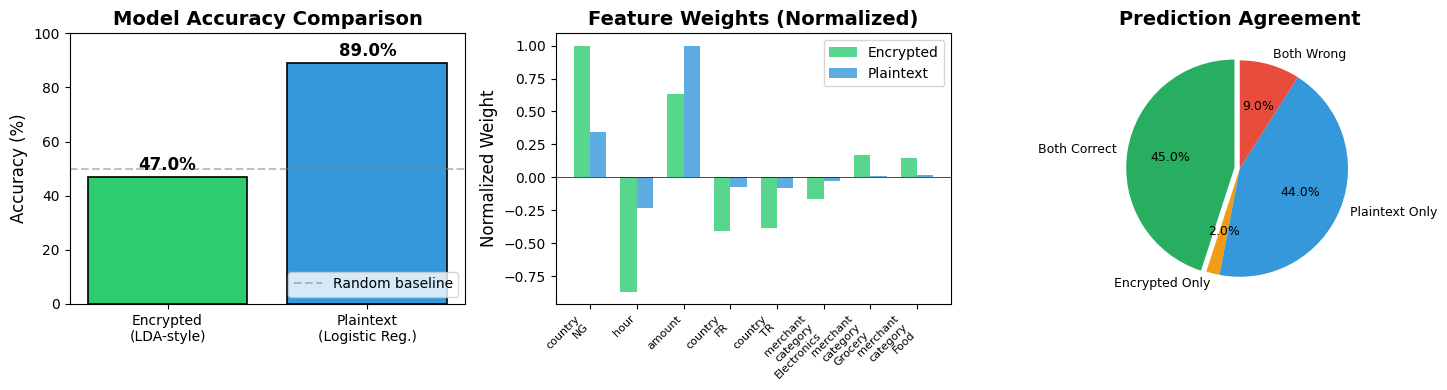


Visualization saved to 'encrypted_vs_plaintext_comparison.png'


In [65]:
# Visualization: Compare model performance
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Accuracy comparison bar chart
ax1 = axes[0]
methods = ['Encrypted\n(LDA-style)', 'Plaintext\n(Logistic Reg.)']
accuracies = [encrypted_accuracy * 100, accuracy_plaintext * 100]
colors = ['#2ecc71', '#3498db']
bars = ax1.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_ylim(0, 100)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('🎯 Model Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax1.legend(loc='lower right')

# 2. Feature importance comparison (top 8)
ax2 = axes[1]
top_features = sorted_features[:8]
x = np.arange(len(top_features))
width = 0.35

enc_vals = [enc_weights_norm.get(f, 0) for f in top_features]
lr_vals = [lr_weights_norm.get(f, 0) for f in top_features]

bars1 = ax2.bar(x - width/2, enc_vals, width, label='Encrypted', color='#2ecc71', alpha=0.8)
bars2 = ax2.bar(x + width/2, lr_vals, width, label='Plaintext', color='#3498db', alpha=0.8)

ax2.set_ylabel('Normalized Weight', fontsize=12)
ax2.set_title('📊 Feature Weights (Normalized)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f.replace('_', '\n') for f in top_features], fontsize=8, rotation=45, ha='right')
ax2.legend(loc='upper right')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 3. Prediction agreement pie chart
ax3 = axes[2]
labels = ['Both Correct', 'Encrypted Only', 'Plaintext Only', 'Both Wrong']
sizes = [both_correct, encrypted_only, plaintext_only, both_wrong]
colors_pie = ['#27ae60', '#f39c12', '#3498db', '#e74c3c']
explode = (0.05, 0, 0, 0)

wedges, texts, autotexts = ax3.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
                                    autopct='%1.1f%%', startangle=90, 
                                    textprops={'fontsize': 9})
ax3.set_title('🤝 Prediction Agreement', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('encrypted_vs_plaintext_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Visualization saved to 'encrypted_vs_plaintext_comparison.png'")